In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, accuracy_score, log_loss, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import shap
from sklearn.metrics import roc_curve, log_loss, accuracy_score

In [9]:
#x_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/x_data.csv')
x_data = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/feature_df_2.csv')
y_data = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/y_data_rms.csv')

In [10]:
x_df = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/feature_df_2.csv')

df = x_df.merge(y_data[['source_file', 'bottom_rms']], on='source_file').reset_index(drop=True)

df = df.dropna(subset=['bottom_rms'])

X = df.drop(columns=['source_file', 'bottom_rms'])
y = df['bottom_rms']

train_rem_idx = int(len(X) * 0.8) # 80% for training, 20% for validation and testing
val_test_idx = int(len(X) * 0.9) # 10% for validation, 10% for testing (from the remaining 20%)

X_train = X.iloc[:train_rem_idx]
X_val = X.iloc[train_rem_idx:val_test_idx]
X_test = X.iloc[val_test_idx:]

y_train = y.iloc[:train_rem_idx]
y_val = y.iloc[train_rem_idx:val_test_idx]
y_test = y.iloc[val_test_idx:]

In [41]:
def objective(trial):
    params = {
        "n_estimators": 5000,
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        #"min_child_weight": trial.suggest_int("min_child_weight", 1, 30),

        #"gamma": trial.suggest_float("gamma", 0, 10),
        #"reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        #"reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
    }
    
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    return mse

import optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

[I 2026-06-07 11:43:09,477] A new study created in memory with name: no-name-b19d1798-af2e-4c5a-9722-f7d36e8361f7


[I 2026-06-07 11:43:18,129] Trial 0 finished with value: 0.0004903632554275984 and parameters: {'max_depth': 2, 'learning_rate': 0.0012303452930963435, 'subsample': 0.8109085518985645, 'colsample_bytree': 0.8129406998893917}. Best is trial 0 with value: 0.0004903632554275984.
[I 2026-06-07 11:43:22,864] Trial 1 finished with value: 0.0004722628097700904 and parameters: {'max_depth': 6, 'learning_rate': 0.006366748780725427, 'subsample': 0.6679919321221317, 'colsample_bytree': 0.860418375966354}. Best is trial 1 with value: 0.0004722628097700904.
[I 2026-06-07 11:43:32,647] Trial 2 finished with value: 0.0004759868997985735 and parameters: {'max_depth': 5, 'learning_rate': 0.0013680745110575192, 'subsample': 0.6792559863673798, 'colsample_bytree': 0.6223581899870406}. Best is trial 1 with value: 0.0004722628097700904.
[I 2026-06-07 11:43:45,922] Trial 3 finished with value: 0.0004773274312791645 and parameters: {'max_depth': 5, 'learning_rate': 0.0010141798344095614, 'subsample': 0.9100

In [50]:
#opt_params = {'n_estimators': 5000, 'max_depth': 10, 'learning_rate': 0.01525803171352834, 'subsample': 0.9361080329155063, 'colsample_bytree': 0.8774494819985844, 
#              'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', "random_state": 42}

opt_params = {'max_depth': 6, 'learning_rate': 0.040194325744109624, 'subsample': 0.763195671226351, 'colsample_bytree': 0.9007039506074228}

final_model = xgb.XGBRegressor(**opt_params, early_stopping_rounds=70)
final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_val)
y_pred_val = final_model.predict(X_val)
y_pred_test = final_model.predict(X_test)

print("Dummy R2:", r2_score(y_val, dummy.predict(X_val)))
print("Model R2 (val):", r2_score(y_val, y_pred_val))
print("Model R2 (test):", r2_score(y_test, y_pred_test))

print("Dummy MAE:", mean_absolute_error(y_val, dummy.predict(X_val)))
print("Model MAE (val):", mean_absolute_error(y_val, y_pred_val))
print("Model MAE (test):", mean_absolute_error(y_test, y_pred_test))

Dummy R2: -0.00012899893564211062
Model R2 (val): 0.19421749825465273
Model R2 (test): 0.2214036189654296
Dummy MAE: 0.018940237953174045
Model MAE (val): 0.017215503021625264
Model MAE (test): 0.018776272858477397


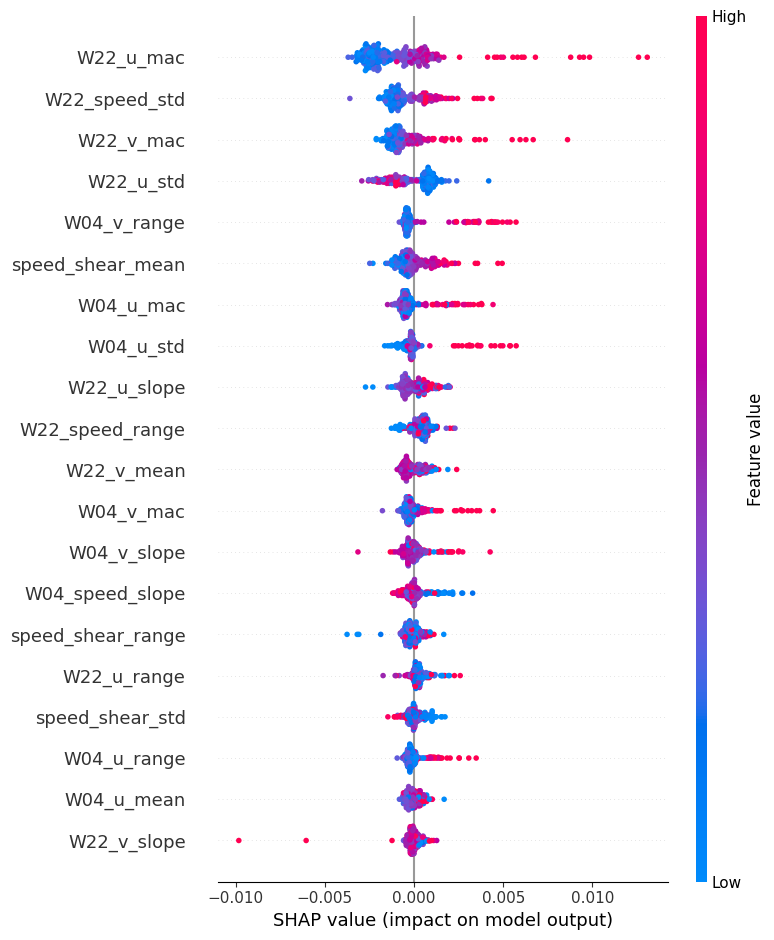

In [51]:
shap_values_final = shap.TreeExplainer(final_model).shap_values(X_val)
shap.summary_plot(shap_values_final, X_val, plot_type="dot")

In [52]:
shap_importance = pd.DataFrame({'feature': X_val.columns, 'shap_importance': 
                                np.abs(shap_values_final).mean(axis=0)}).sort_values(by='shap_importance', ascending=False)



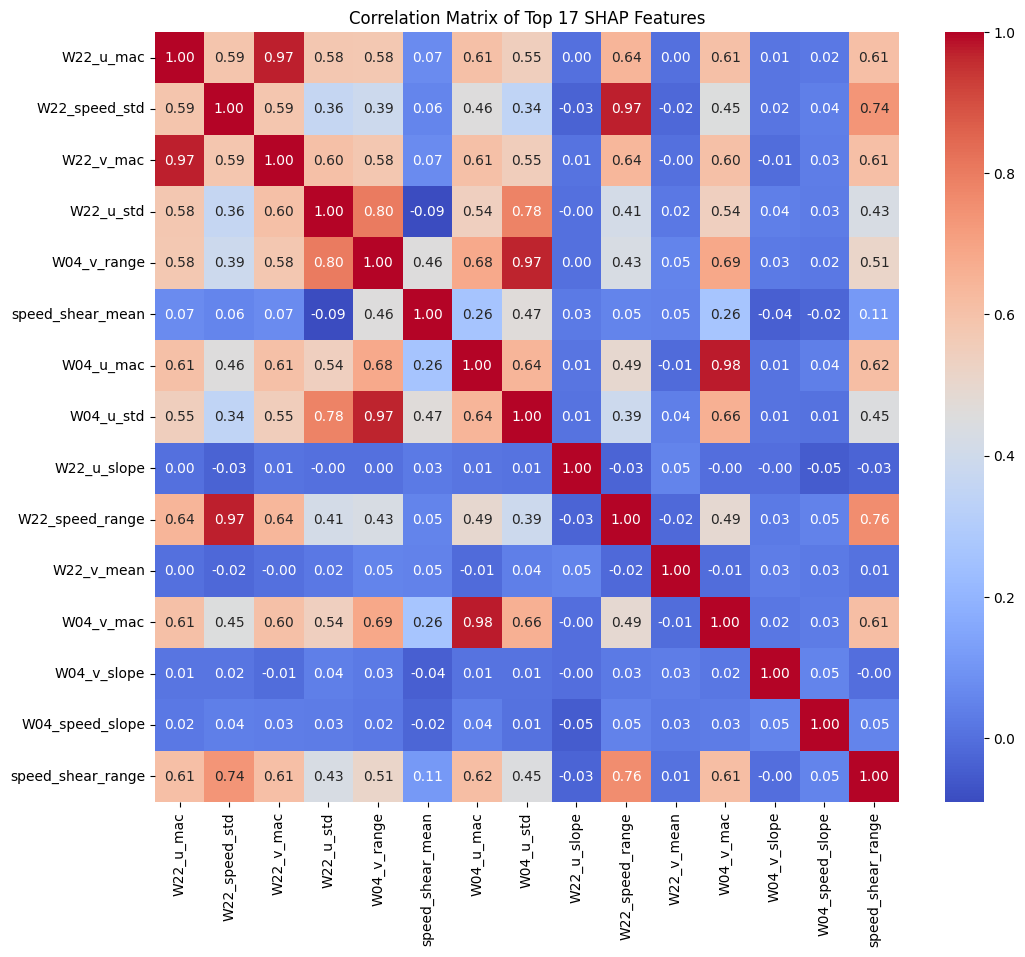

In [54]:
top_features_shap = shap_importance['feature'].head(15).tolist()
corr_matrix = X_train[top_features_shap].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top 17 SHAP Features')
plt.show()

In [55]:
print(shap_importance.head(15)) 

              feature  shap_importance
17          W22_u_mac         0.001848
30      W22_speed_std         0.001039
23          W22_v_mac         0.001033
13          W22_u_std         0.000987
9         W04_v_range         0.000802
34   speed_shear_mean         0.000706
5           W04_u_mac         0.000688
1           W04_u_std         0.000578
16        W22_u_slope         0.000566
32    W22_speed_range         0.000520
18         W22_v_mean         0.000474
11          W04_v_mac         0.000447
10        W04_v_slope         0.000429
28    W04_speed_slope         0.000418
37  speed_shear_range         0.000363


['W22_u_mac', 'W22_speed_std', 'W22_v_mac', 'W22_u_std', 'W04_v_range', 'speed_shear_mean', 'W04_u_mac', 'W22_u_slope', 'W22_speed_range', 'W22_v_mean', 'W04_v_mac', 'W04_v_slope', 'W04_speed_slope', 'speed_shear_range']


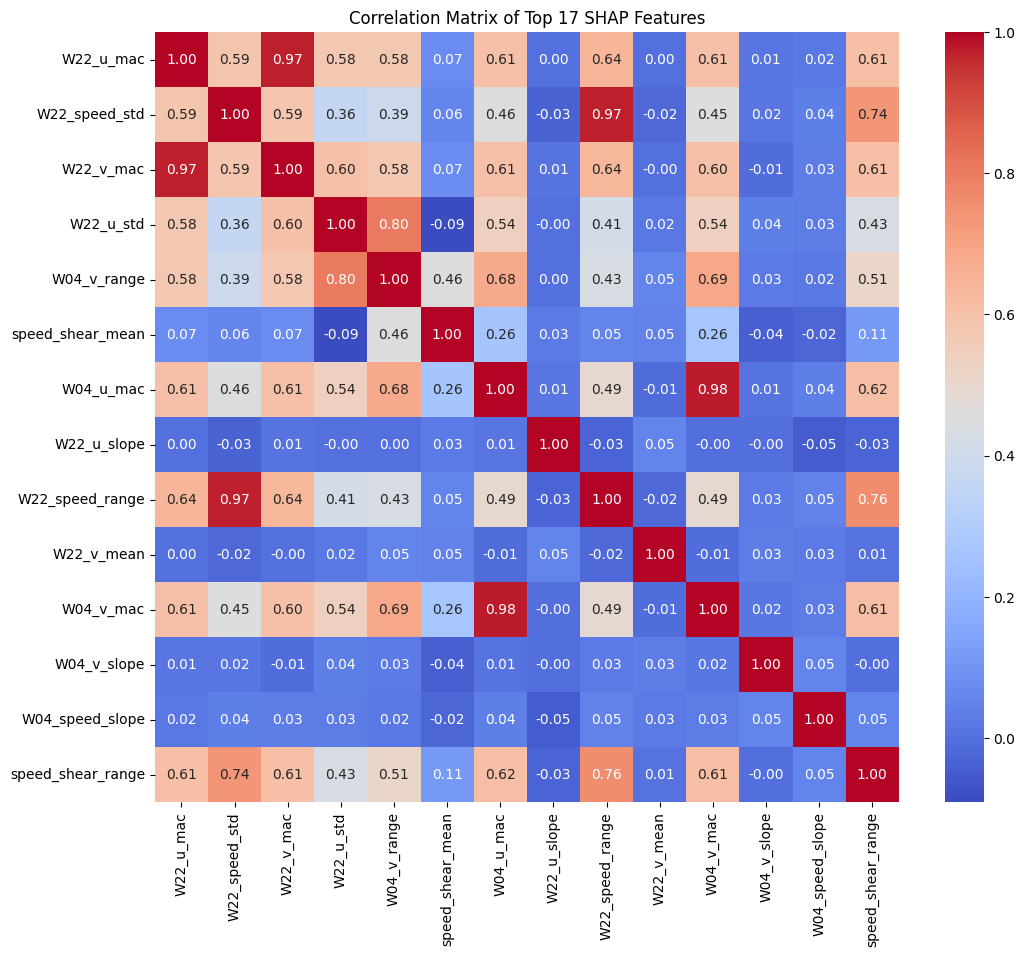

In [63]:
top_features_shap_ny = top_features_shap.copy()
top_features_shap_ny.remove('W04_u_std')

corr_matrix_ny = X_train[top_features_shap_ny].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_ny, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top 17 SHAP Features')
print(top_features_shap_ny)
plt.show()

In [57]:
#plt.hist(y_test, bins=20, alpha=0.5, label='True Values')
#plt.hist(y_pred_test, bins=20, alpha=0.5, label='Predicted Values')
#plt.xlabel('Max Vertical Acceleration')
#plt.ylabel('Frequency')
#plt.title('Distribution of True vs Predicted Max Vertical Acceleration')
#plt.axvline(np.mean(y_test), color='blue', linestyle='dashed', linewidth=1, label='Mean True Values')
#plt.axvline(np.mean(y_pred_test), color='orange', linestyle='dashed', linewidth=1, label='Mean Predicted Values')
#plt.legend()
#plt.show()

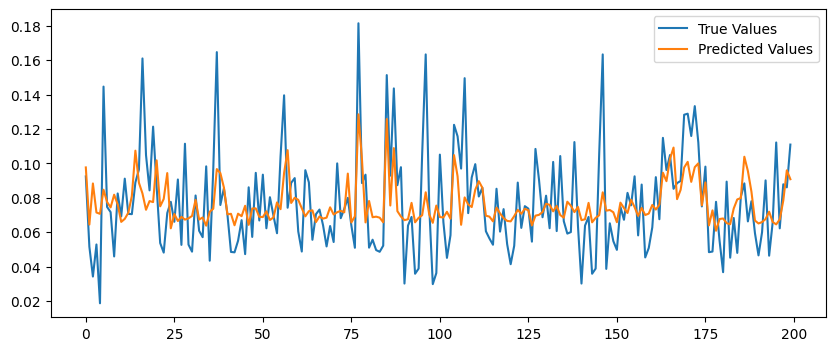

In [62]:
x_axis = np.arange(len(y_test))
plt.figure(figsize=(10,4))
plt.plot(x_axis[:200], y_test[:200], label='True Values')
plt.plot(x_axis[:200], y_pred_test[:200], label='Predicted Values')
plt.legend()
plt.show()